# 03 · Map-Reduce (fan-out / fan-in with `Send`)

**Idea:** Split a big job into many *independent* pieces, process them **in parallel** (map),
then combine the results (reduce).

```
START -> fan_out ==Send==> summarize_one (x N, parallel) ==> reduce -> END
```

LangGraph's `Send("node", payload)` launches one copy of a node per item — even when you don't know
the number of items until runtime.

* **Map** = the cheap tiny model `qwen3:0.6b` (many small summaries)
* **Reduce** = the stronger `llama3.1` (one careful final answer)

In [ ]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

In [ ]:
import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

class OverallState(TypedDict):
    documents: list[str]
    summaries: Annotated[list[str], operator.add]   # reducer: parallel workers APPEND safely
    final: str

class WorkerState(TypedDict):        # the private input each parallel worker gets
    document: str

In [ ]:
def fan_out(state: OverallState):
    """Conditional edge that returns a LIST of Send objects = one parallel task per document."""
    docs = [Send("summarize_one", {"document": d}) for d in state["documents"]]
    print(docs)
    return docs


def summarize_one(state: WorkerState):
    """MAP step: runs once per document, all in parallel."""
    print(">>>>>>>summarize_one>>>>>",state['document'])
    s = small_llm.invoke(f"Summarize in ONE short sentence:\n{state['document']}").content
    print(">>>>>>>summarize_one_content>>>>>",s)
    return {"summaries": [s]}          # appended to OverallState.summaries


def reduce_summaries(state: OverallState):
    """REDUCE step: runs once, after ALL map workers finished."""
    bullets = "\n".join(f"- {s}" for s in state["summaries"])
    final = llm.invoke(f"Combine these notes into one 2-sentence overview:\n{bullets}").content
    return {"final": final}

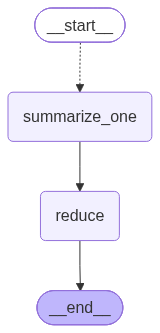

In [ ]:
builder = StateGraph(OverallState)
builder.add_node("summarize_one", summarize_one)
builder.add_node("reduce", reduce_summaries)

builder.add_conditional_edges(START, fan_out, ["summarize_one"])   # fan-out
builder.add_edge("summarize_one", "reduce")                        # fan-in (waits for all)
builder.add_edge("reduce", END)
graph = builder.compile()
from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
docs = [
    "Solar panels convert sunlight to electricity. Costs have fallen by about 90% in the last decade.",
    "Wind turbines generate power from moving air. Offshore farms produce steadier output than onshore ones.",
    "Hydropower uses flowing water to spin turbines. It is reliable but dams can disrupt river ecosystems.",
    "Geothermal plants tap underground heat. They run 24/7 but are limited to certain regions.",
]
out = graph.invoke({"documents": docs})
print("MAP results:"); [print(" •", s) for s in out["summaries"]]
print("\nREDUCE result:\n", out["final"])

[Send(node='summarize_one', arg={'document': 'Solar panels convert sunlight to electricity. Costs have fallen by about 90% in the last decade.'}), Send(node='summarize_one', arg={'document': 'Wind turbines generate power from moving air. Offshore farms produce steadier output than onshore ones.'}), Send(node='summarize_one', arg={'document': 'Hydropower uses flowing water to spin turbines. It is reliable but dams can disrupt river ecosystems.'}), Send(node='summarize_one', arg={'document': 'Geothermal plants tap underground heat. They run 24/7 but are limited to certain regions.'})]
>>>>>>>summarize_one>>>>> Solar panels convert sunlight to electricity. Costs have fallen by about 90% in the last decade.
>>>>>>>summarize_one>>>>> Wind turbines generate power from moving air. Offshore farms produce steadier output than onshore ones.
>>>>>>>summarize_one>>>>> Hydropower uses flowing water to spin turbines. It is reliable but dams can disrupt river ecosystems.
>>>>>>>summarize_one>>>>> Geo

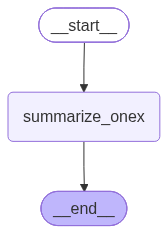

['Solar panels, wind turbines, hydropower, and geothermal plants have reduced costs and provided reliable energy sources.']


In [ ]:
class GraphState(TypedDict):
    document: str
    summaries: Annotated[list[str], operator.add]
    
def summarize_onex(state: GraphState):
    """MAP step: runs once per document, all in parallel."""
    prompt = f"Summarize in ONE short sentence:\n{state['document']}"
    s = small_llm.invoke(prompt).content
    return {"summaries": [s]}    

 

builder = StateGraph(GraphState)
builder.add_node("summarize_onex", summarize_onex)
 

builder.add_edge(START, "summarize_onex")   # fan-out
builder.add_edge("summarize_onex", END)                        # fan-in (waits for all)
 
graph = builder.compile()
from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

docs = [
    "Solar panels convert sunlight to electricity. Costs have fallen by about 90% in the last decade.",
    "Wind turbines generate power from moving air. Offshore farms produce steadier output than onshore ones.",
    "Hydropower uses flowing water to spin turbines. It is reliable but dams can disrupt river ecosystems.",
    "Geothermal plants tap underground heat. They run 24/7 but are limited to certain regions.",
]
 
result = graph.invoke({"document": docs})
print(result["summaries"])

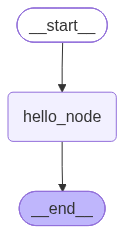

World


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. Define the state schema
class GraphState(TypedDict):
    documentd: str

# 2. Define the single node function
def say_hello(state: GraphState) -> dict:
    """Takes state and returns updated state dictionary."""
    return {"text": f"{state['documentd']} hello"}

# 3. Build the graph
builder = StateGraph(GraphState)

# Add node
builder.add_node("hello_node", say_hello)

# Add edges: START -> node -> END
builder.add_edge(START, "hello_node")
builder.add_edge("hello_node", END)

# Compile into a runnable graph
graph = builder.compile()
from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))
# 4. Run the graph
result = graph.invoke({"documentd": "World"})

print(result["documentd"])
# Output: World hello

### Good to know
* Workers run concurrently, so **order of `summaries` is not guaranteed**. Put an index in the payload if order matters.
* Same shape works for: per-file code review, per-page PDF extraction, parallel web searches, batch classification.
* This is also the **Orchestrator-Worker** pattern when the orchestrator (an LLM) decides *at runtime* what the pieces are.